# What people ask Edmonton Open Data for, and what happens to it

**Dataset:** *Dataset Requests* (`a9w6-s3na`) on `data.edmonton.ca`. It is
refreshed daily and holds every request since automated intake began on
2016-01-26.

**Two jobs:**

1. **Duplicate check (§6).** Before this project sends a data request, find
   out whether someone has already asked for it and what the City answered.
2. **Landscape (§3–§5).** What people request over time, what gets published,
   and what gets refused or left open.

⚠️ **Read §2 before quoting any count.** The table mixes two intake systems
with different status vocabularies. In December 2023, 126 refused requests
were re-entered as new ones, and a single-day bulk edit in August 2026 reset
`status_date` on 241 rows. Counted naively, the table double-counts requests
and misdates decisions.

## Reproducing

```
pip install pandas matplotlib certifi
```

Public endpoint, no API token.

In [1]:
import json
import re
import ssl
import urllib.parse
import urllib.request
from datetime import datetime, timezone

import certifi
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

UA = "edmonton-tax-viz/dataset-requests (open-data landscape)"
SSL_CTX = ssl.create_default_context(cafile=certifi.where())
RUN_AT = datetime.now(timezone.utc)
REQUESTS = "a9w6-s3na"
LIMIT = 50000

pd.set_option("display.max_colwidth", 90, "display.width", 200)

CHECKS: list[tuple[bool, str]] = []


def check(ok: bool, claim: str) -> None:
    CHECKS.append((bool(ok), claim))
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")


def soda(dataset: str, params: dict) -> list[dict]:
    url = (f"https://data.edmonton.ca/resource/{dataset}.json?"
           + urllib.parse.urlencode(params))
    req = urllib.request.Request(url, headers={"User-Agent": UA})
    with urllib.request.urlopen(req, context=SSL_CTX, timeout=120) as r:
        return json.loads(r.read())


raw = pd.DataFrame(soda(REQUESTS, {"$limit": LIMIT}))
d = raw.copy()
for c in ["request_creation_date", "status_date", "dataset_published_date"]:
    d[c] = pd.to_datetime(d[c])
d["department"] = d["department"].fillna("(blank)")

display(Markdown(f"**Snapshot.** Executed against live data **{RUN_AT:%Y-%m-%d}** "
                 f"(UTC): **{len(d):,} requests**, created "
                 f"{d.request_creation_date.min():%Y-%m-%d} to "
                 f"{d.request_creation_date.max():%Y-%m-%d}. The source changes "
                 "daily, so re-execute before citing a figure."))
check(len(d) < LIMIT, f"one page holds the whole table ({len(d)} < {LIMIT}), so no rows were cut off")
check(d.request_number.is_unique, "request_number is unique")

**Snapshot.** Executed against live data **2026-09-22** (UTC): **656 requests**, created 2016-01-26 to 2026-08-19. The source changes daily, so re-execute before citing a figure.

  [PASS] one page holds the whole table (656 < 50000), so no rows were cut off
  [PASS] request_number is unique


## 1. Two intake systems, two status vocabularies

`request_number` gives away which system took the request:

* **`ODRyy-nnn`**: the original intake, from 2016 until its last entry in
  2024. Statuses are Title-case: `Completed`, `Rejected`, `Declined`,
  `Cancelled`, `New`.
* **Opaque ids such as `868…`**: the newer tracker, from October 2021 on.
  Statuses are UPPER-case: `NEW`, `IN PROGRESS`, `PAUSED`, `CLOSED`.

⚠️ **The newer system has no way to say "refused" and no way to say
"published".** Everything that ends goes to `CLOSED`. Old-system outcomes
therefore can't be compared one-for-one with new-system outcomes, and
`CLOSED` is shown below as its own bucket instead of being folded into
"done".

In [2]:
d["system"] = d.request_number.str.startswith("ODR").map({True: "ODR (old)", False: "tracker (new)"})
print(pd.crosstab(d.status, d.system, margins=True))
print()
print(d.groupby("system").request_creation_date.agg(["min", "max", "count"]))

OUTCOME = {
    "Completed": "Completed",
    "Rejected": "Refused", "Declined": "Refused",
    "CLOSED": "Closed (reason not given)",
    "NEW": "Open", "New": "Open", "IN PROGRESS": "Open", "PAUSED": "Open",
    "Cancelled": "Withdrawn",
}
d["outcome"] = d.status.map(OUTCOME)
unmapped = sorted(d.loc[d.outcome.isna(), "status"].unique())
check(not unmapped, f"every status maps to an outcome bucket (unmapped: {unmapped or 'none'})")
d["outcome"] = d.outcome.fillna("Unmapped")

system       ODR (old)  tracker (new)  All
status                                    
CLOSED               0            152  152
Cancelled           19              0   19
Completed          146              0  146
Declined            50              0   50
IN PROGRESS          0             24   24
NEW                  0             92   92
New                  1              0    1
PAUSED               0             18   18
Rejected           154              0  154
All                370            286  656

                              min                 max  count
system                                                      
ODR (old)     2016-01-26 15:32:27 2024-09-06 15:40:23    370
tracker (new) 2021-10-29 09:30:13 2026-08-19 15:37:21    286
  [PASS] every status maps to an outcome bucket (unmapped: none)


### `dataset_published_date` on a `CLOSED` row does not mean something was published

Every `CLOSED` row has a `dataset_published_date`, including requests the
City could not have fulfilled publicly. One example is below. On the new
tracker the field is best read as "date closed".

In [3]:
closed = d[d.status == "CLOSED"]
check(closed.dataset_published_date.notna().all(),
      f"all {len(closed)} CLOSED rows carry a dataset_published_date")
ex = d[d.request_details.fillna("").str.contains("will not be publicly visible")]
print(ex[["request_number", "status", "dataset_published_date", "request_description", "request_details"]].to_string(index=False))

  [PASS] all 152 CLOSED rows carry a dataset_published_date
request_number status dataset_published_date                                                                        request_description                                                                                                                                                                       request_details
     8688a6173 CLOSED    2024-06-14 15:17:57 Property and Education Tax Rates prior to 2014 and as far back as available, ideally 1960? This information is requested to perform modeling of historical changes to the assessment values of properties before 2014. This is a private study and will not be publicly visible.
     8688a6366 CLOSED    2024-06-14 15:17:12                                         Historical Property Assessment Data prior to 2012.                                                                                                                Ideally between 1960 and 2012, this data will not be publ

## 2. Two artifacts that distort naive counts

### 2a. The December 2023 re-intake

On 2023-12-12 and 2023-12-13, requests that the old system had **refused or
declined** were re-entered in the new tracker under new ids and new creation
dates. That creates a spike of more than 100 "requests" in a single month.
The pairs are matched here by normalised title.

This matters in two ways:

* **For volume over time:** each re-intake row is the same request counted
  twice, so §3 drops those rows.
* **For what gets refused:** the re-intake shows the City **reconsidering its
  refusals**. The crosstab shows where those requests stand now.

In [4]:
norm = lambda s: re.sub(r"[^a-z0-9]", "", str(s).lower())
d["title_key"] = d.request_description.map(norm)
odr = d[d.system == "ODR (old)"]
reintake_window = d.request_creation_date.between("2023-12-12", "2023-12-14")
d["reintake"] = (d.system == "tracker (new)") & reintake_window & d.title_key.isin(odr.title_key)

pairs = (d[d.reintake]
         .merge(odr[["title_key", "request_number", "status", "request_creation_date"]],
                on="title_key", suffixes=("", "_orig"))
         .drop_duplicates("request_number"))
print(f"re-intake rows: {d.reintake.sum()} "
      f"(of {(reintake_window & (d.system == 'tracker (new)')).sum()} tracker rows created in the window)")
print("\nOriginal old-system status  ×  status after re-intake:")
print(pd.crosstab(pairs.status_orig, pairs.status, margins=True))
check(d.reintake.sum() >= 100, f"the Dec-2023 re-intake is still visible ({d.reintake.sum()} rows)")
check(set(pairs.status_orig) <= {"Rejected", "Declined", "Completed"},
      "re-intake originals were refused/declined (plus at most a stray Completed)")

re-intake rows: 126 (of 127 tracker rows created in the window)

Original old-system status  ×  status after re-intake:
status       CLOSED  IN PROGRESS  NEW  PAUSED  All
status_orig                                       
Completed         1            0    0       0    1
Declined         10            7    6       0   23
Rejected         42            7   49       4  102
All              53           14   55       4  126
  [PASS] the Dec-2023 re-intake is still visible (126 rows)
  [PASS] re-intake originals were refused/declined (plus at most a stray Completed)


### 2b. `status_date` is the date the row was last edited, not the date of the decision

Large blocks of rows share a single `status_date`. That is a bulk edit, not
hundreds of decisions made on one day. Durations such as "time to decision"
computed from `status_date` are therefore unreliable on the new tracker, and
this notebook doesn't compute them.

In [5]:
top_days = d.status_date.dt.date.value_counts().head(5)
print(top_days)
biggest = top_days.index[0]
print(f"\n{biggest}: statuses on the bulk-edit day")
print(d[d.status_date.dt.date == biggest].status.value_counts())
check(top_days.iloc[0] >= 100, f"a bulk status_date sweep is present ({top_days.iloc[0]} rows on {biggest})")

status_date
2026-08-19    241
2023-12-13    104
2026-08-26     32
2023-12-12     23
2023-09-19     16
Name: count, dtype: int64

2026-08-19: statuses on the bulk-edit day
status
CLOSED         139
NEW             62
IN PROGRESS     24
PAUSED          16
Name: count, dtype: int64
  [PASS] a bulk status_date sweep is present (241 rows on 2026-08-19)


## 3. Volume over time

Requests by the year they were **first** made, with re-intake rows removed.
Colours show each request's current outcome.

outcome,Completed,Refused,Closed (reason not given),Open,Withdrawn,total
year,,,,,,
2016,46,51,0,0,14,111
2017,28,33,0,0,1,62
2018,26,22,0,0,3,51
2019,17,33,0,0,1,51
2020,14,25,0,0,0,39
2021,10,6,2,4,0,22
2022,2,14,4,0,0,20
2023,3,20,19,5,0,47
2024,0,0,33,22,0,55


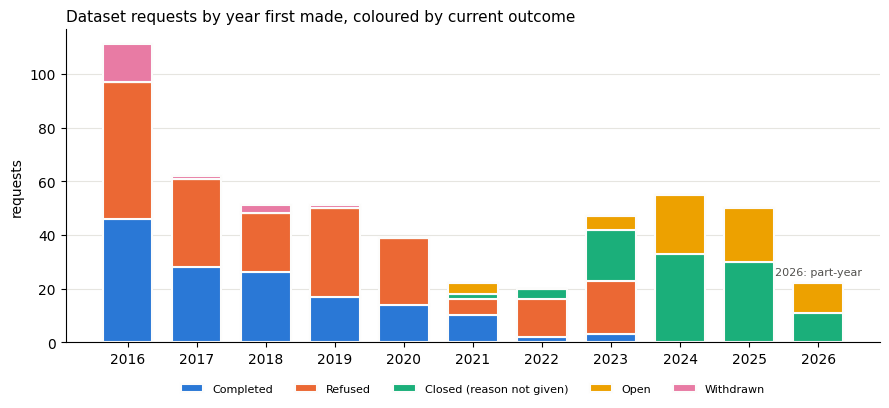

In [6]:
u = d[~d.reintake].copy()
u["year"] = u.request_creation_date.dt.year
ORDER = ["Completed", "Refused", "Closed (reason not given)", "Open", "Withdrawn"]
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # dataviz reference palette, slots 1-5 in order
by_year = pd.crosstab(u.year, u.outcome).reindex(columns=ORDER, fill_value=0)
display(by_year.assign(total=by_year.sum(axis=1)))

fig, ax = plt.subplots(figsize=(9, 4.2))
bottom = pd.Series(0, index=by_year.index)
for col, colour in zip(ORDER, COLOURS):
    ax.bar(by_year.index, by_year[col], bottom=bottom, color=colour, label=col,
           width=0.72, edgecolor="#fcfcfb", linewidth=1.5)
    bottom += by_year[col]
ax.set_title("Dataset requests by year first made, coloured by current outcome", loc="left", fontsize=11)
ax.set_ylabel("requests")
ax.set_xticks(by_year.index)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.1))
this_year = RUN_AT.year
ax.annotate(f"{this_year}: part-year", (this_year, by_year.loc[this_year].sum() if this_year in by_year.index else 0),
            textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="#52514e")
plt.tight_layout()
plt.show()

**How to read it:**

* 2016 was the intake's first year and is its busiest. Only 11 of its rows
  are hackathon whiteboard captures (measured 2026-09-22), so hackathons
  don't explain the peak.
* Everything filed after the switch to the new tracker is either
  `Closed (reason not given)` or still `Open`. The drop in blue and orange
  after 2022 comes from the vocabulary change in §1. It is not a change in
  how the City decides.

## 4. What people request

Topics are assigned by keyword over title and details. Each request goes to
the **first** topic in the list below that matches, so every request is
counted once. This is a transparent heuristic, not a classifier, and the
patterns are printed so they can be argued with.

In [7]:
TOPICS = [
    ("Transit", r"\bets\b|transit|\bbus|lrt|gtfs|arc card|ridership|\btrain"),
    ("Property, assessment & tax", r"assess|parcel|propert|\btax|\blot\b|lot size|title"),
    ("Planning, permits & zoning", r"permit|zoning|land use|development|bylaw \d|\barp\b|rezon|licen[cs]e"),
    ("Roads, traffic & mobility", r"road|traffic|collision|speed|parking|snow|sidewalk|bike|cycl|pathway|pedestrian|intersection|radar|scooter|micromobility|bridge|pedway"),
    ("Utilities & drainage", r"drain|sewer|water|epcor|\bgas\b|power|electric|utilit"),
    ("Public safety", r"crime|police|fire|911|emergenc|bylaw enforcement|complain"),
    ("Parks, trees & environment", r"\bpark|tree|green|waste|garbage|trash|recycl|climate|emission|river|ravine|natural area|cemeter|washroom|picnic|graffiti|ashtray|flood"),
    ("Recreation, library & community", r"recreation|library|leisure|community|arena|pool|school|playground"),
    ("People & census", r"census|population|demograph|income|housing|homeless|senior"),
    ("Budget & spending", r"budget|spend|\bcost|expend|revenue|contract|procure|salar|financial statement|expense|severance|capital project|renewal invest|funding|earnings"),
    ("Council, elections & administration", r"council|election|\bward|voting|candidate|meeting|motion|agenda|lobby|foip|\b311\b|job|rfp|disclosure"),
    ("Base maps & imagery", r"lidar|orthophoto|imagery|elevation|\bdem\b|postal code|neighbou?rhood (?:dataset|boundar)|manhole|historic resource"),
]


def topic_of(text: str) -> str:
    t = text.lower()
    for name, pat in TOPICS:
        if re.search(pat, t):
            return name
    return "Other / unclassified"


u["text"] = u.request_description.fillna("") + " " + u.request_details.fillna("")
u["topic"] = u.text.map(topic_of)
u["era"] = pd.cut(u.year, [2015, 2019, 2022, 2100], labels=["2016–19", "2020–22", "2023–now"])
tt = pd.crosstab(u.topic, u.era, margins=True, margins_name="all").sort_values("all", ascending=False)
display(tt)
print(f"unclassified: {(u.topic == 'Other / unclassified').mean():.0%} of requests")

era,2016–19,2020–22,2023–now,all
topic,,,,
all,275,81,174,530
Other / unclassified,45,15,23,83
"Roads, traffic & mobility",52,10,18,80
"Property, assessment & tax",24,6,31,61
"Planning, permits & zoning",23,12,17,52
Transit,22,7,21,50
"Council, elections & administration",24,5,13,42
"Parks, trees & environment",22,9,9,40
Utilities & drainage,18,8,7,33


unclassified: 16% of requests


## 5. What gets blocked

### 5a. Refusal rate by topic, old system only

Only the old system records a refusal, so this table is limited to `ODR`
rows, which cover 2016 to 2024. The denominator is requests that reached a
decision (`Completed` or `Refused`).

In [8]:
old = u[u.system == "ODR (old)"]
dec = old[old.outcome.isin(["Completed", "Refused"])]
rr = (dec.groupby("topic").outcome
      .agg(decided="size", refused=lambda s: (s == "Refused").sum()))
rr["refused_share"] = (rr.refused / rr.decided).round(2)
display(rr.sort_values("decided", ascending=False))
print(f"overall: {rr.refused.sum()} of {rr.decided.sum()} decided old-system requests refused "
      f"({rr.refused.sum() / rr.decided.sum():.0%})")

,decided,refused,refused_share
topic,,,
"Roads, traffic & mobility",58,38,0.66
Other / unclassified,55,23,0.42
"Planning, permits & zoning",35,22,0.63
"Council, elections & administration",30,13,0.43
"Property, assessment & tax",30,20,0.67
"Parks, trees & environment",29,17,0.59
Transit,28,15,0.54
Utilities & drainage,28,21,0.75
"Recreation, library & community",20,11,0.55


overall: 204 of 350 decided old-system requests refused (58%)


### 5b. Refusal by department

Department is mostly blank on refusals, so this table says little about
*who* refuses.

In [9]:
print(pd.crosstab(dec.department, dec.outcome).assign(n=lambda t: t.sum(axis=1))
      .sort_values("n", ascending=False).head(12))

outcome                        Completed  Refused    n
department                                            
(blank)                               40       97  137
City Operations                       29       31   60
Financial Services                    27       31   58
Urban Planning and Economy            18       12   30
Community Services                    18       10   28
Office of the City Clerk               8        4   12
EPCOR                                  0        7    7
Communications and Engagement          3        3    6
Infrastructure Services                1        4    5
Transportation Services                1        2    3
External User                          0        1    1
Library                                0        1    1


### 5c. The open backlog

Requests still `NEW`, `IN PROGRESS` or `PAUSED`, aged from the **original**
request date. A re-intake row is dated back to its old-system original.

In [10]:
orig_date = pairs.set_index("request_number").request_creation_date_orig
d["first_asked"] = d.request_number.map(orig_date).fillna(d.request_creation_date)
openq = d[d.outcome == "Open"].copy()
openq["age_years"] = ((pd.Timestamp(RUN_AT.date()) - openq.first_asked.dt.tz_localize(None)).dt.days / 365.25).round(1)
print(f"{len(openq)} open requests; median age {openq.age_years.median()} years; "
      f"{(openq.age_years >= 5).sum()} first asked five or more years ago")
print(openq.status.value_counts().to_string())
print("\nOldest ten:")
print(openq.sort_values("first_asked")[["request_number", "status", "first_asked", "request_description"]]
      .head(10).assign(first_asked=lambda t: t.first_asked.dt.date).to_string(index=False))

135 open requests; median age 4.0 years; 59 first asked five or more years ago
status
NEW            92
IN PROGRESS    24
PAUSED         18
New             1

Oldest ten:
request_number      status first_asked                             request_description
     8686q3fqq IN PROGRESS  2016-08-17                              Drinking Fountains
     8686q3h0j IN PROGRESS  2016-08-25 Request for water cost information for Edmonton
     8686q3jxm         NEW  2016-10-16                         FOIP Requests (content)
     8686q3mtu         NEW  2016-10-27                        311 - Daily Call Summary
     8686q3qck         NEW  2016-11-07              Travel Expenses for City Employees
     8686q3ta4 IN PROGRESS  2017-01-23             Waterbodies in the city of Edmonton
     8686q3tz0 IN PROGRESS  2017-03-04           Bridge clearance (esp. low clearance)
     8686qg87v IN PROGRESS  2017-05-31                        Top of Bank Spatial Data
     8686qg8x6 IN PROGRESS  2017-06-27        

### 5d. Asked again and again

Titles that appear more than once after the re-intake is removed, meaning
different people asked for the same thing. Titles are grouped loosely, by a
keyword such as "parcel", because requesters word the same ask differently.
A cluster here is demand the City has seen repeatedly.

In [11]:
CLUSTERS = {
    "parcel / lot polygons": r"parcel|lot (?:line|polygon|boundar)",
    "property assessment extra fields / history": r"assess",
    "zoning": r"zoning",
    "transit ridership / ARC": r"ridership|arc card",
    "crime": r"crime",
    "snow": r"snow",
    "trees": r"tree",
}
rows = []
for name, pat in CLUSTERS.items():
    hit = u[u.request_description.fillna("").str.lower().str.contains(pat)]
    rows.append((name, len(hit), hit.year.min(), hit.year.max(),
                 ", ".join(f"{k} {v}" for k, v in hit.outcome.value_counts().items())))
display(pd.DataFrame(rows, columns=["cluster (title match)", "requests", "first", "last", "outcomes"])
        .sort_values("requests", ascending=False))

,cluster (title match),requests,first,last,outcomes
1,property assessment extra fields / history,20,2016,2026,"Closed (reason not given) 9, Refused 5, Withdrawn 2, Completed 2, Open 2"
6,trees,10,2016,2024,"Refused 5, Completed 3, Open 1, Closed (reason not given) 1"
0,parcel / lot polygons,9,2016,2026,"Refused 4, Closed (reason not given) 4, Withdrawn 1"
3,transit ridership / ARC,8,2018,2024,"Refused 4, Open 4"
2,zoning,6,2019,2025,"Refused 4, Open 1, Closed (reason not given) 1"
4,crime,5,2016,2024,"Completed 2, Withdrawn 1, Refused 1, Open 1"
5,snow,3,2016,2020,Refused 3


## 6. Duplicate check: has anyone already asked for what we are about to ask?

Each project ask is searched against title and details, including the
re-intake rows, so no answer is missed. The asks come from
`docs/DATA_ISSUES.md`. Two are **dataset requests** (issues 4 and 5). The
rest are **defect reports** about datasets that already exist, which would
not normally go through this channel. They are searched anyway, to catch
anyone who reported the same problem as a request.

⚠️ **No hits means no match for these patterns on the run date.** Read the
near-misses before concluding that nobody asked.

In [12]:
OUR_ASKS = [
    ("Issue 4: taxable/exempt status per assessment account",
     r"exempt|non-?taxable|tax code|tax status|liabilit"),
    ("Issue 5: school locations for private / charter / francophone operators",
     r"private school|charter|francophone|independent school|school (?:site|location)"),
    ("Issue 1: q7d6-ambg 'Period of Coverage' year",
     r"q7d6|period of coverage|current calendar year"),
    ("Issue 3: historical assessment roll (qi6a-xuwt) gaps",
     r"qi6a|historical (?:property )?assess"),
    ("Issue 6: permits' neighbourhood field (24uj-dj8v)",
     r"24uj|building permit.*neighbourhood|general building permit"),
    ("Issue 7: stt5-pzaa frozen",
     r"stt5"),
    ("Context: other asks for more assessment fields",
     r"assessment (?:data|variables|dataset)|additional fields|lot (?:size|width)"),
]
text_all = (d.request_description.fillna("") + " " + d.request_details.fillna("")).str.lower()
summary = []
for label, pat in OUR_ASKS:
    hit = d[text_all.str.contains(pat, regex=True)]
    summary.append((label, len(hit)))
    display(Markdown(f"#### {label}\n`{pat}`: **{len(hit)} hit(s)**"))
    if len(hit):
        display(hit.sort_values("request_creation_date")
                [["request_number", "request_creation_date", "status", "department", "request_description"]]
                .assign(request_creation_date=lambda t: t.request_creation_date.dt.date)
                .reset_index(drop=True))

#### Issue 4: taxable/exempt status per assessment account
`exempt|non-?taxable|tax code|tax status|liabilit`: **0 hit(s)**

#### Issue 5: school locations for private / charter / francophone operators
`private school|charter|francophone|independent school|school (?:site|location)`: **4 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR19-241,2019-03-02,Completed,Financial Services,School Sites geospatial data
1,ODR19-263,2019-09-05,Rejected,(blank),School Site boundary For Catholic Schools
2,8686agd98,2023-11-06,CLOSED,(blank),climate and vulnerability risk assessment
3,8686qh58b,2023-12-13,CLOSED,(blank),School Site boundary For Catholic Schools


#### Issue 1: q7d6-ambg 'Period of Coverage' year
`q7d6|period of coverage|current calendar year`: **2 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR23-363,2023-04-27,Rejected,(blank),Added data columns to Property Assessment Data (Current Calendar Year)
1,868kczkej,2026-07-16,CLOSED,(blank),Year Built as of January 2010 - Data Request


...

#### Issue 6: permits' neighbourhood field (24uj-dj8v)
`24uj|building permit.*neighbourhood|general building permit`: **3 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR18-185,2018-03-22,Completed,Urban Planning and Economy,Development Permits
1,ODR20-301,2020-07-17,Rejected,(blank),Adding Account Number to the General Building Permit dataset
2,8686qhh84,2023-12-13,NEW,(blank),Adding Account Number to the General Building Permit dataset


#### Issue 7: stt5-pzaa frozen
`stt5`: **0 hit(s)**

#### Context: other asks for more assessment fields
`assessment (?:data|variables|dataset)|additional fields|lot (?:size|width)`: **13 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR16-54,2016-06-14,Completed,Financial Services,Property assessment data - current and historical
1,ODR19-233,2019-02-04,Rejected,(blank),"Add the Land Use, Zoning & Effective Zoning to Property Assessment dataset"
2,ODR19-245,2019-04-24,Rejected,(blank),Expose additional fields to the Property Assessment Data dataset.
3,860phgmq3,2023-01-11,CLOSED,(blank),2023 Assessment Data Release
4,ODR23-363,2023-04-27,Rejected,(blank),Added data columns to Property Assessment Data (Current Calendar Year)
5,8686qh18m,2023-12-13,CLOSED,(blank),"Add the Land Use, Zoning & Effective Zoning to Property Assessment dataset"
6,8686qh3ah,2023-12-13,CLOSED,(blank),Expose additional fields to the Property Assessment Data dataset.
7,868889taf,2024-04-19,CLOSED,(blank),Construction Year of Building for Assessment Data
8,8688a6366,2024-04-25,CLOSED,(blank),Historical Property Assessment Data prior to 2012.
9,868ev2c47,2025-07-19,NEW,(blank),Historical property assessment data that includes lot width.


### What the hits mean for each ask

(Written against the run of 2026-09-22. Re-read the tables above when
re-executing.)

* **Issue 4 (exemption status):** nobody has requested it. The request
  would be new. The context block lists other requests for more assessment
  fields. They run from 2016 to 2026 and are mostly refused or closed without
  a stated reason. `868ev4dbu`, which asks for a list of assessment
  variables, is still `NEW`. A draft could cite this record, and should be
  ready for a similar answer.
* **Issue 5 (schools):** every earlier request was for **school-site
  polygons** for the two public boards. `ODR19-241` (public schools) was
  Completed. The Catholic request was Rejected as `ODR19-263`, re-entered in
  the re-intake, and is now `CLOSED` as `8686qh58b`. Nobody has asked for
  private, charter or francophone operators. The request would be new, and
  those precedents are worth citing.
* **Issue 6 (permits):** nobody has reported the defect. One related ask,
  **adding the assessment account number to the General Building Permit
  dataset** (`ODR20-301`, Rejected, re-entered as `8686qhh84`, still `NEW`),
  would give permits a clean join key. It is worth mentioning alongside the
  defect report.
* **Issues 1, 3 and 7:** nobody has reported these defects. The hits only
  share wording: the dataset's own title contains "Current Calendar Year",
  and the historical-assessment requests ask for years **before 2012**, not
  for accounts missing from 2012 onward. That was expected, because defect
  reports go to `opendata@edmonton.ca`, not to the request form.

In [13]:
display(pd.DataFrame(summary, columns=["ask", "hits"]))

,ask,hits
0,Issue 4: taxable/exempt status per assessment account,0
1,Issue 5: school locations for private / charter / francophone operators,4
2,Issue 1: q7d6-ambg 'Period of Coverage' year,2
3,Issue 3: historical assessment roll (qi6a-xuwt) gaps,3
4,Issue 6: permits' neighbourhood field (24uj-dj8v),3
5,Issue 7: stt5-pzaa frozen,0
6,Context: other asks for more assessment fields,13


## Invariants

These guard the notebook's own readings of the data: the re-intake, the
bulk-edit date, and the status mapping. If one fails, the upstream table has
changed shape and the prose above is stale.

In [14]:
passed = sum(1 for ok, _ in CHECKS if ok)
display(Markdown(f"### {passed} of {len(CHECKS)} invariants passed"))
for ok, claim in CHECKS:
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")
if passed != len(CHECKS):
    raise AssertionError(f"{len(CHECKS) - passed} invariant(s) failed — see above")

### 7 of 7 invariants passed

  [PASS] one page holds the whole table (656 < 50000), so no rows were cut off
  [PASS] request_number is unique
  [PASS] every status maps to an outcome bucket (unmapped: none)
  [PASS] all 152 CLOSED rows carry a dataset_published_date
  [PASS] the Dec-2023 re-intake is still visible (126 rows)
  [PASS] re-intake originals were refused/declined (plus at most a stray Completed)
  [PASS] a bulk status_date sweep is present (241 rows on 2026-08-19)
